# T4 Churn signal explorer (gold layer)

**Goal (delivery plan, T4).** Test the behavioural hypotheses about what comes before churn, and report which ones really separate churners from players who stay, so that only signals that work become features (T5, T6), and the ones that fail are recorded so nobody tests them again.

**Data.** The gold layer, 18 months (from 2025-04-01). Each signal is computed per player at each cutoff **from data up to the cutoff only**:
- most come from `gld_player_signals_daily` on the cutoff day, and 7 and 30 days before it for the trends;
- the ones that need the day-by-day history (deposit days, losing streak, big win then withdrawal, withdrawal without redeposit, prior dormancy) come from `gld_player_financial_daily` and the activity cache;
- failed deposits come from `gld_player_payments_daily`, which only starts on 2025-09-18.

**Population and label.** At each cutoff, the players of brand 64 with a bet in the 30 days up to it; the label is the 60-day churn of `docs/churn_definition_v0.md` (no bet in the next 60 days).

**Cutoffs.** The first day of 12 months, **training months only**: 2025-06-01 to 2026-05-01. The later cutoffs are kept for the test month and the backtest.

**The same four numbers for every signal** (module `eda/signal_explorer.py`):
1. **Lift**: churn rate with the signal / without it (flags), or highest quartile / lowest quartile (continuous), with a 95% interval.
2. **Hazard ratio**: univariate Cox PH on the time to churn, per 1 SD of the value (sign-log) or for the flag, 95% interval clustered by player.
3. **AUC** of the signal alone for the 60-day label (above 0.5: a higher value means more churn).
4. **Stability**: the lift at each of the 12 cutoffs; a signal whose effect flips side over time is dropped.

**Decision rule.** PROMOTED when the hazard-ratio interval excludes 1, |AUC - 0.5| >= 0.05, the effect never flips side and lift, hazard ratio and AUC point the same way. Otherwise REJECTED, with the reason. Two references are scored too, not as candidates: days since the last bet (the recency rule) and gold's own `churn_score` (the platform's current rule).

In [1]:
import datetime as dt
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lifelines import KaplanMeierFitter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "eda" else Path.cwd().resolve()
sys.path[:0] = [str(PROJECT_ROOT / "eda"), str(PROJECT_ROOT / "src" / "features")]
import gold_cache
import signal_explorer as se

BRAND = 64
TRAINING_CUTOFFS = [d.date() for d in pd.date_range("2025-06-01", "2026-05-01", freq="MS")]
OUT = PROJECT_ROOT / f"data/03_output/signals/brand{BRAND}"
OUT.mkdir(parents=True, exist_ok=True)
FRAME_PATH = PROJECT_ROOT / f"data/02_intermediate/signal_frame_brand{BRAND}.parquet"
COLORS = {"PROMOTED": "#2a9d8f", "REJECTED": "#b0b0b0", "REFERENCE": "#e76f51"}
pd.set_option("display.width", 220)
print(f"{len(TRAINING_CUTOFFS)} training cutoffs: {TRAINING_CUTOFFS[0]} to {TRAINING_CUTOFFS[-1]}")

12 training cutoffs: 2025-06-01 to 2026-05-01


## 1. Data: the gold caches

Only the missing days are read from S3, in parallel (plus the last 7, which gold reprocesses). `activity` is shared by every brand; `financial` and `payments` keep brand 64 only. The signal snapshots (36 days: each cutoff, 7 and 30 days before) are read when the frame is built. Needs a valid AWS SSO session the first time.

In [2]:
t0 = time.time()
gold_cache.build("activity")
gold_cache.build("financial", BRAND)
gold_cache.build("payments", BRAND)
DATA_END = gold_cache.cached_days("activity")[-1]
print(f"data up to {DATA_END} ({time.time() - t0:.0f}s)")

gold cache activity: 7 day(s) (2026-09-30 to 2026-10-06, 190,705 rows) in 1s
gold cache financial brand 64: 7 day(s) (2026-09-30 to 2026-10-06, 17,106 rows) in 4s
gold cache payments brand 64: 7 day(s) (2026-09-30 to 2026-10-06, 16,626 rows) in 1s
data up to 2026-10-06 (11s)


## 2. The frame: one row per player and cutoff

In [3]:
t0 = time.time()
frame = se.build_frame(TRAINING_CUTOFFS, BRAND, DATA_END)
frame.to_parquet(FRAME_PATH, index=False)
print(f"{len(frame):,} player-cutoffs, {frame['player_key'].nunique():,} players, churn {frame[se.LABEL].mean():.1%} "
      f"({time.time() - t0:.0f}s) -> {FRAME_PATH.relative_to(PROJECT_ROOT)}")
frame.groupby("cutoff_date").agg(players=("player_key", "size"), churn_60d=(se.LABEL, "mean")).style.format({"churn_60d": "{:.1%}"})

  2025-06-01: 34,106 players, churn 53.0%, in gold signals 100.0%
  2025-07-01: 27,427 players, churn 53.0%, in gold signals 100.0%
  2025-08-01: 19,120 players, churn 40.7%, in gold signals 100.0%
  2025-09-01: 18,433 players, churn 37.9%, in gold signals 100.0%
  2025-10-01: 19,279 players, churn 39.2%, in gold signals 100.0%
  2025-11-01: 22,163 players, churn 47.0%, in gold signals 100.0%
  2025-12-01: 17,727 players, churn 50.6%, in gold signals 100.0%
  2026-01-01: 14,569 players, churn 50.3%, in gold signals 100.0%
  2026-02-01: 11,878 players, churn 37.9%, in gold signals 100.0%
  2026-03-01: 12,622 players, churn 36.7%, in gold signals 100.0%
  2026-04-01: 13,187 players, churn 37.3%, in gold signals 100.0%
  2026-05-01: 12,823 players, churn 35.6%, in gold signals 100.0%


/home/javier/whizdom-churn/eda/signal_explorer.py:276: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["player_key"] = frame["tenant_id"].astype(str) + ":" + frame["player_id"].astype(str)


223,334 player-cutoffs, 94,481 players, churn 44.9% (35s) -> data/02_intermediate/signal_frame_brand64.parquet


,players,churn_60d
cutoff_date,,
2025-06-01,34106,53.0%
2025-07-01,27427,53.0%
2025-08-01,19120,40.7%
2025-09-01,18433,37.9%
2025-10-01,19279,39.2%
2025-11-01,22163,47.0%
2025-12-01,17727,50.6%
2026-01-01,14569,50.3%
2026-02-01,11878,37.9%


## 3. The four numbers for every signal

Sorted by how far the AUC is from 0.5. `as_expected`: the observed direction matches the plan's hypothesis.

In [4]:
# SLOW COMPILING!!
t0 = time.time()
table, per_cutoff = se.evaluate_all(frame)
table.to_csv(OUT / "signal_summary.csv", index=False)
per_cutoff.to_csv(OUT / "lift_by_cutoff.csv", index=False)
print(f"{len(table)} signals in {time.time() - t0:.0f}s: {table['decision'].value_counts().to_dict()}")
cols = ["signal", "hypothesis", "coverage", "churn_rate_high", "churn_rate_low", "lift", "lift_low95", "lift_high95",
        "hazard_ratio", "hr_low95", "hr_high95", "auc", "flips", "as_expected", "decision", "reason"]
(table[cols].style
 .format({"coverage": "{:.0%}", "churn_rate_high": "{:.1%}", "churn_rate_low": "{:.1%}", "lift": "{:.2f}",
          "lift_low95": "{:.2f}", "lift_high95": "{:.2f}", "hazard_ratio": "{:.2f}", "hr_low95": "{:.2f}",
          "hr_high95": "{:.2f}", "auc": "{:.3f}"}, na_rep="")
 .apply(lambda r: [f"background-color: {COLORS[r['decision']]}33"] * len(r), axis=1)
 .hide(axis="index"))

33 signals in 127s: {'PROMOTED': 21, 'REJECTED': 11, 'REFERENCE': 1}


signal,hypothesis,coverage,churn_rate_high,churn_rate_low,lift,lift_low95,lift_high95,hazard_ratio,hr_low95,hr_high95,auc,flips,as_expected,decision,reason
engagement_score,Engagement,100%,7.8%,77.1%,0.10,0.10,0.10,0.46,0.45,0.46,0.181,0,True,PROMOTED,
n_deposit_days_30d,Deposit frequency,12%,3.9%,62.5%,0.06,0.06,0.07,0.40,0.40,0.41,0.211,0,True,PROMOTED,
days_since_last_deposit,Deposit recency,12%,62.5%,6.4%,9.75,8.87,10.72,2.23,2.19,2.28,0.774,0,True,PROMOTED,
tenure_days,Tenure,100%,24.5%,84.4%,0.29,0.29,0.30,0.49,0.49,0.50,0.232,0,True,PROMOTED,
days_since_last_bet,Bet recency,100%,71.1%,13.9%,5.10,4.99,5.21,1.73,1.72,1.73,0.758,0,True,PROMOTED,
deposited_within_14d,Deposit recency,12%,15.5%,55.3%,0.28,0.27,0.29,0.28,0.28,0.29,0.286,0,True,PROMOTED,
games_breadth_30d,Product narrowing,100%,21.4%,69.2%,0.31,0.30,0.31,0.62,0.62,0.62,0.287,0,True,PROMOTED,
n_deposit_days_7d,Deposit frequency,12%,7.1%,48.8%,0.15,0.13,0.16,0.48,0.47,0.49,0.300,0,True,PROMOTED,
deposited_within_7d,Deposit recency,12%,9.7%,49.7%,0.20,0.18,0.21,0.27,0.26,0.28,0.309,0,True,PROMOTED,
deposit_frequency_score,Deposit frequency,12%,12.1%,48.8%,0.25,0.23,0.27,0.56,0.55,0.57,0.320,0,True,PROMOTED,


## 4. Ranking: AUC and hazard ratio, with intervals

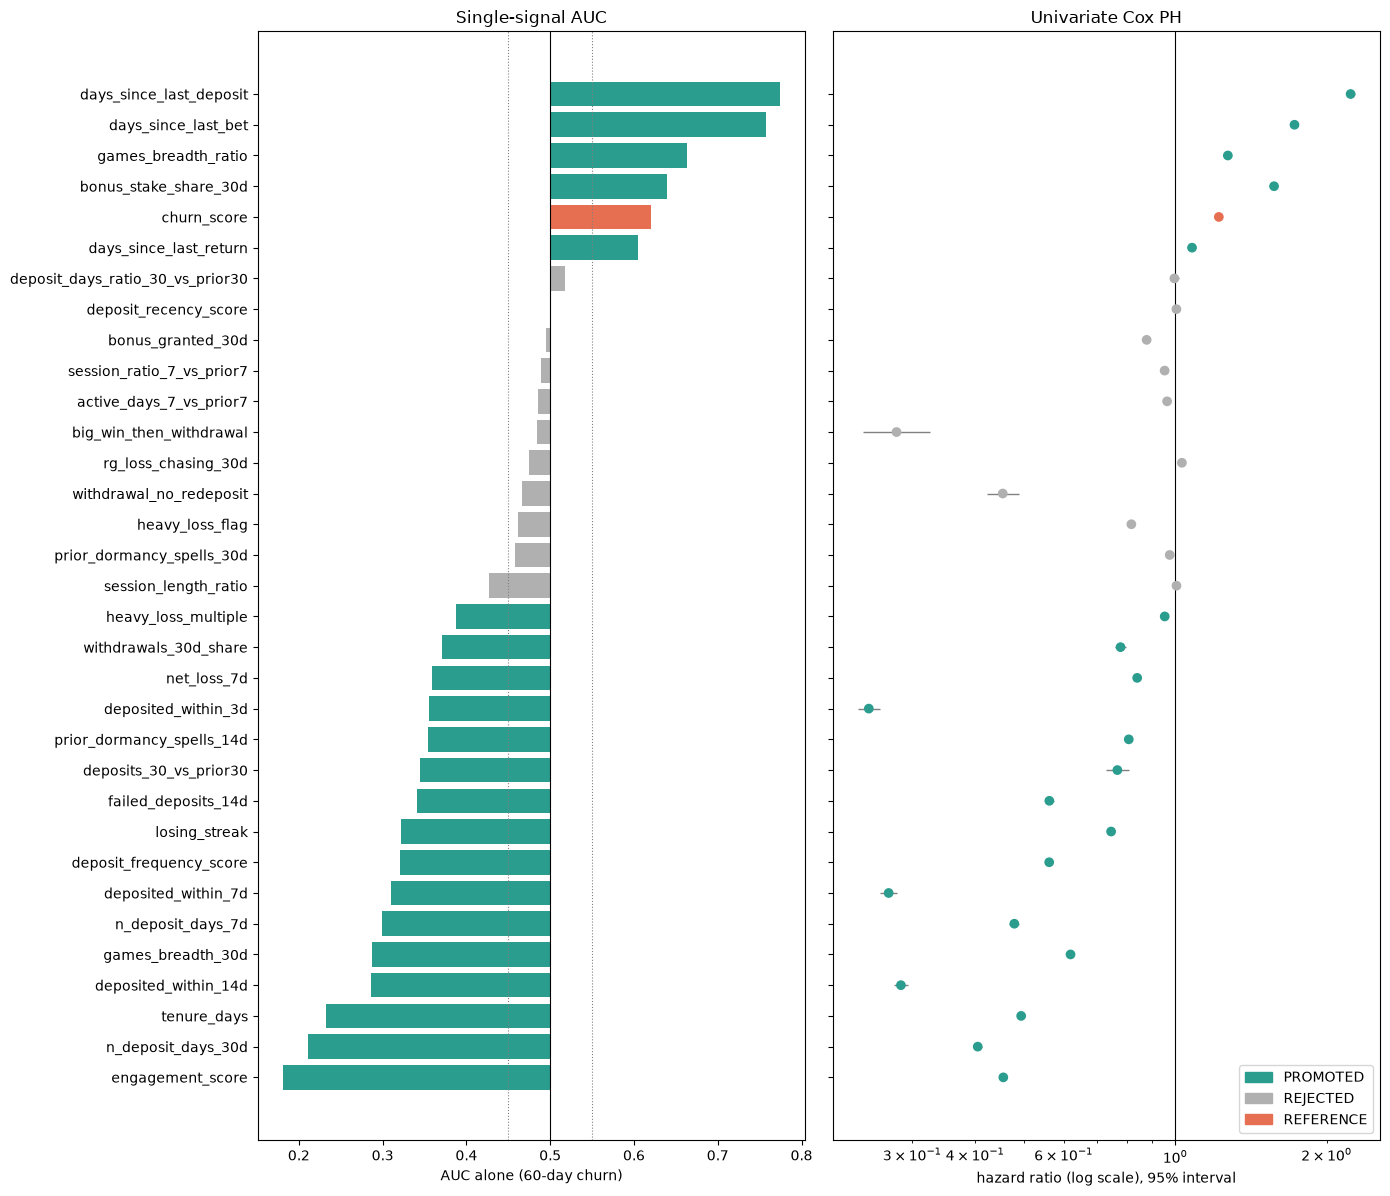

In [5]:
t = table.sort_values("auc")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 0.32 * len(t) + 1.5), sharey=True)
y = np.arange(len(t))
ax1.barh(y, t["auc"] - 0.5, left=0.5, color=[COLORS[d] for d in t["decision"]])
ax1.axvline(0.5, color="black", linewidth=0.8)
for v in (0.5 - se.MIN_AUC_GAP, 0.5 + se.MIN_AUC_GAP):
    ax1.axvline(v, color="grey", linestyle=":", linewidth=0.8)
ax1.set_yticks(y, t["signal"]); ax1.set_xlabel("AUC alone (60-day churn)"); ax1.set_title("Single-signal AUC")
ax2.errorbar(t["hazard_ratio"], y, xerr=[t["hazard_ratio"] - t["hr_low95"], t["hr_high95"] - t["hazard_ratio"]],
             fmt="none", ecolor="grey", elinewidth=1)
ax2.scatter(t["hazard_ratio"], y, c=[COLORS[d] for d in t["decision"]], zorder=3)
ax2.axvline(1, color="black", linewidth=0.8); ax2.set_xscale("log")
ax2.set_xlabel("hazard ratio (log scale), 95% interval"); ax2.set_title("Univariate Cox PH")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()]
ax2.legend(handles, COLORS.keys(), loc="lower right")
fig.tight_layout(); fig.savefig(OUT / "ranking.png", dpi=120); plt.show()

## 5. Stability: the lift at every cutoff

Log scale, centred on 1 (no effect). A row that changes colour from one cutoff to another flips side: the signal is not stable over time.

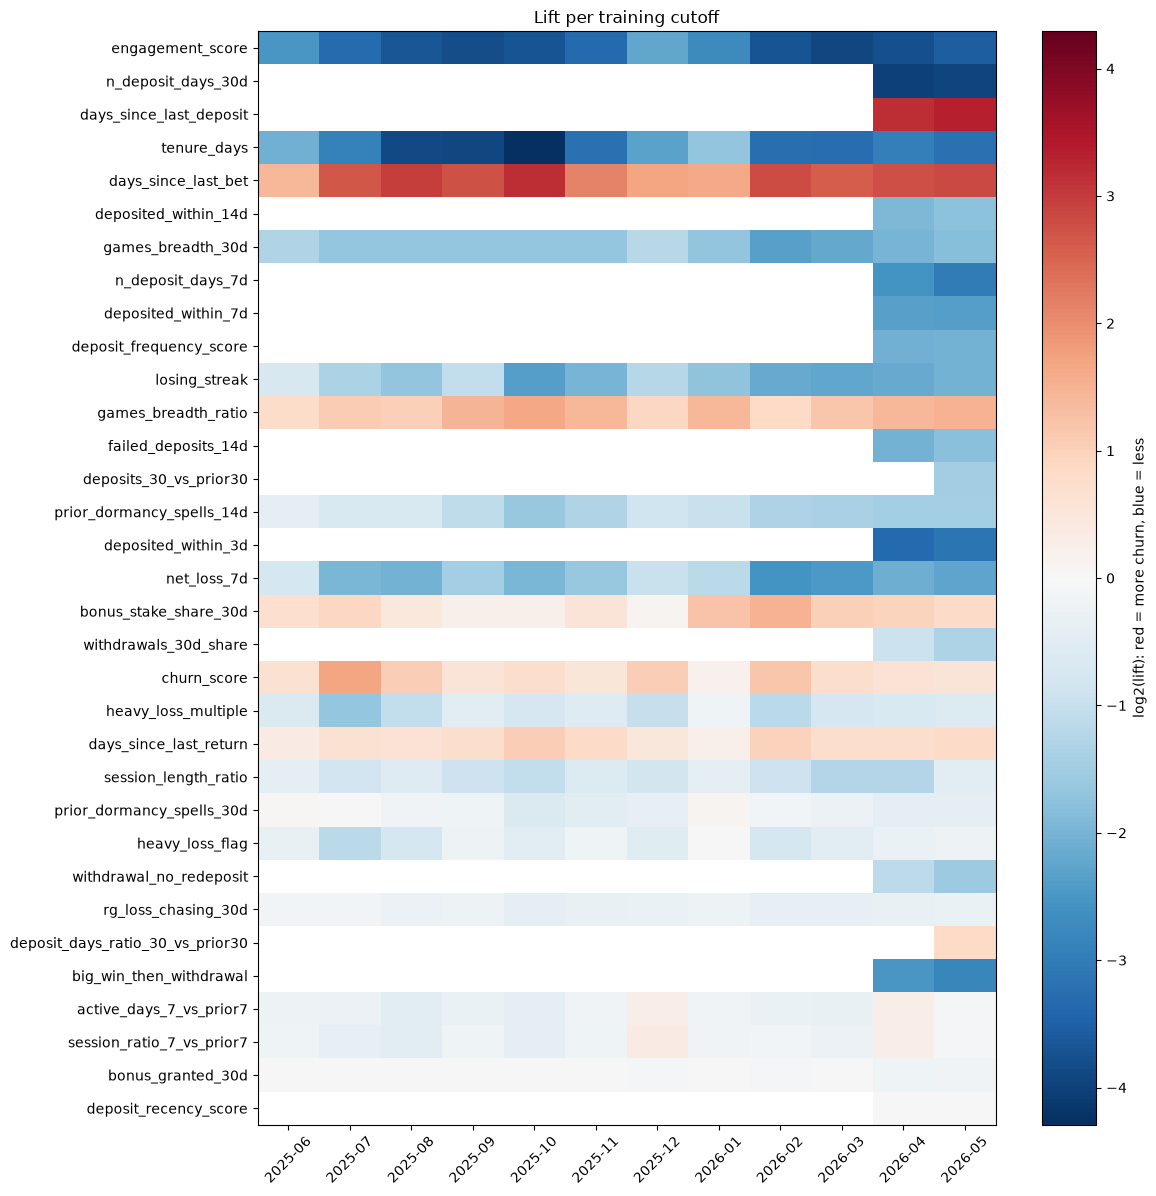

In [6]:
heat = per_cutoff.pivot(index="signal", columns="cutoff_date", values="lift").reindex(table["signal"])
fig, ax = plt.subplots(figsize=(12, 0.32 * len(heat) + 1.5))
lim = np.nanmax(np.abs(np.log2(heat.to_numpy(dtype=float)))) if heat.notna().any().any() else 1
im = ax.imshow(np.log2(heat.to_numpy(dtype=float)), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_yticks(range(len(heat)), heat.index); ax.set_xticks(range(heat.shape[1]), [str(c)[:7] for c in heat.columns], rotation=45)
fig.colorbar(im, ax=ax, label="log2(lift): red = more churn, blue = less")
ax.set_title("Lift per training cutoff")
fig.tight_layout(); fig.savefig(OUT / "lift_stability.png", dpi=120); plt.show()

## 6. Kaplan-Meier curves of the top ten promoted signals

Time to churn after the cutoff, highest vs lowest quartile (or present vs absent). The further apart the curves, the stronger the signal.

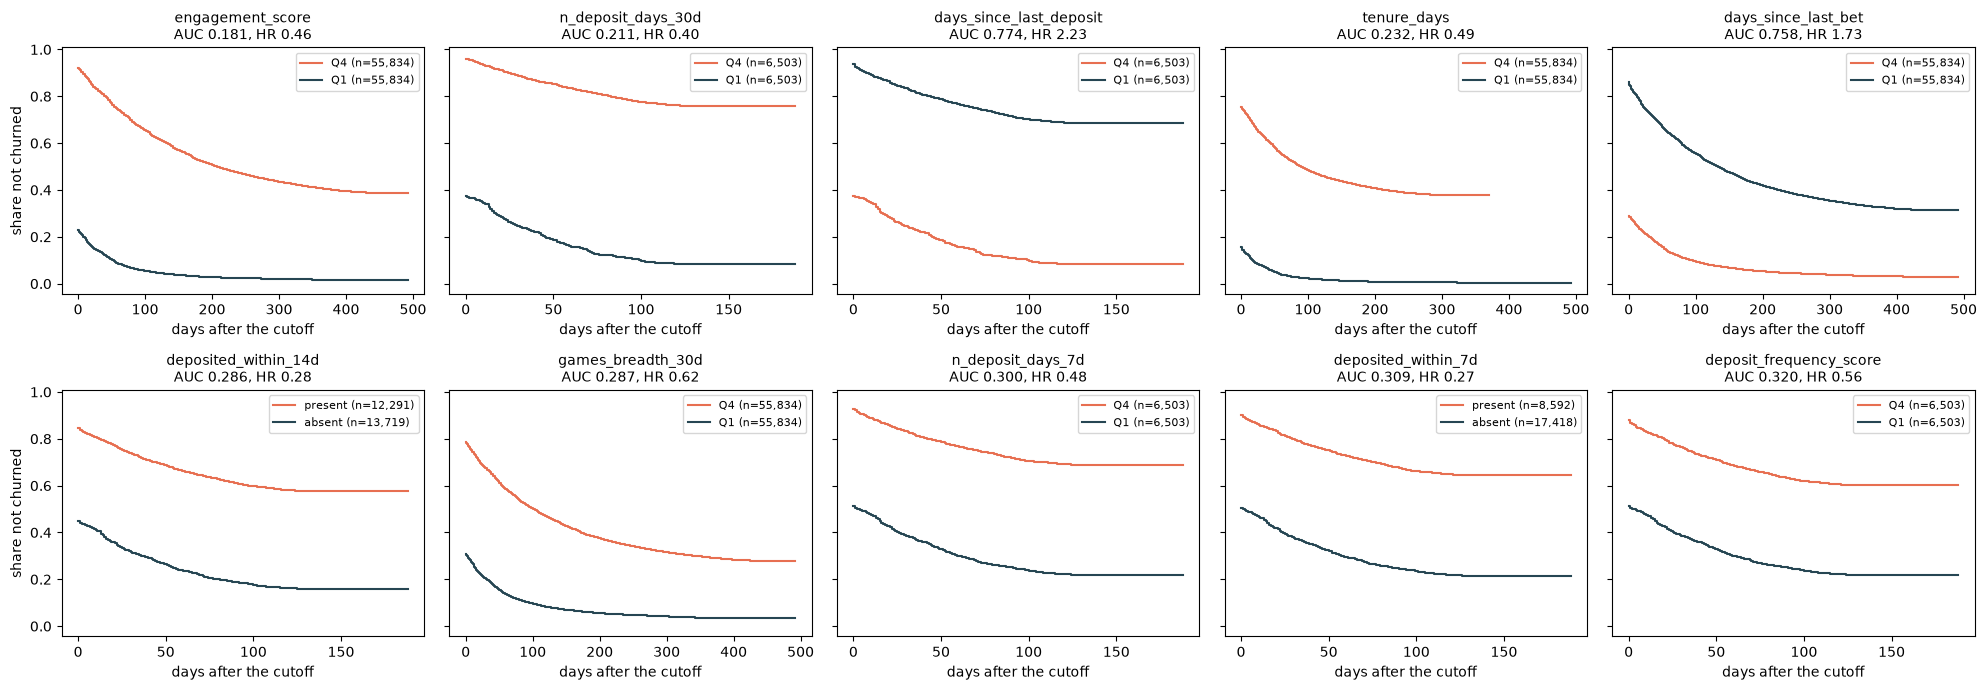

In [7]:
top = table[table["decision"] == "PROMOTED"].head(10)
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=True)
for ax, row in zip(axes.flat, top.itertuples()):
    sig = next(s for s in se.SIGNALS if s.name == row.signal)
    df = frame[frame[row.signal].notna()]
    g = se.groups(df[row.signal], sig.kind)
    hi, lo = ("present", "absent") if sig.kind == "flag" else ("Q4", "Q1")
    for grp, color in ((hi, "#e76f51"), (lo, "#264653")):
        part = df[g == grp]
        KaplanMeierFitter().fit(part["duration_days"], part["event_observed"], label=f"{grp} (n={len(part):,})") \
            .plot_survival_function(ax=ax, ci_show=False, color=color)
    ax.set_title(f"{row.signal}\nAUC {row.auc:.3f}, HR {row.hazard_ratio:.2f}", fontsize=10)
    ax.set_xlabel("days after the cutoff"); ax.legend(fontsize=8)
for ax in axes.flat[len(top):]:
    ax.axis("off")
axes[0, 0].set_ylabel("share not churned"); axes[1, 0].set_ylabel("share not churned")
fig.tight_layout(); fig.savefig(OUT / "km_top10.png", dpi=120); plt.show()

## 7. Promoted and rejected, by hypothesis

In [8]:
for decision in ("PROMOTED", "REJECTED", "REFERENCE"):
    part = table[table["decision"] == decision]
    print(f"\n{decision} ({len(part)})")
    display(part[["hypothesis", "signal", "auc", "hazard_ratio", "lift", "as_expected", "reason"]]
            .sort_values(["hypothesis", "auc"]).style.format({"auc": "{:.3f}", "hazard_ratio": "{:.2f}", "lift": "{:.2f}"}, na_rep="")
            .hide(axis="index"))


PROMOTED (21)


hypothesis,signal,auc,hazard_ratio,lift,as_expected,reason
Bet recency,days_since_last_bet,0.758,1.73,5.10,True,
Big win then withdrawal,withdrawals_30d_share,0.371,0.78,0.46,False,
Bonus dependence,bonus_stake_share_30d,0.639,1.57,1.61,True,
Deposit frequency,n_deposit_days_30d,0.211,0.40,0.06,True,
Deposit frequency,n_deposit_days_7d,0.300,0.48,0.15,True,
Deposit frequency,deposit_frequency_score,0.320,0.56,0.25,True,
Deposit recency,deposited_within_14d,0.286,0.28,0.28,True,
Deposit recency,deposited_within_7d,0.309,0.27,0.20,True,
Deposit recency,deposited_within_3d,0.355,0.25,0.11,True,
Deposit recency,days_since_last_deposit,0.774,2.23,9.75,True,



REJECTED (11)


hypothesis,signal,auc,hazard_ratio,lift,as_expected,reason
Big win then withdrawal,big_win_then_withdrawal,0.484,0.28,0.16,False,AUC within 0.05 of 0.5
Bonus dependence,bonus_granted_30d,0.495,0.88,0.99,True,AUC within 0.05 of 0.5
Deposit frequency,deposit_days_ratio_30_vs_prior30,0.518,1.00,1.83,False,"hazard ratio interval includes 1; AUC within 0.05 of 0.5; lift, hazard ratio and AUC disagree on the direction"
Deposit recency,deposit_recency_score,0.500,1.01,1.01,True,"hazard ratio interval includes 1; AUC within 0.05 of 0.5; lift, hazard ratio and AUC disagree on the direction"
Heavy loss,heavy_loss_flag,0.461,0.82,0.73,False,AUC within 0.05 of 0.5
Heavy loss,rg_loss_chasing_30d,0.474,1.03,0.86,False,"AUC within 0.05 of 0.5; lift, hazard ratio and AUC disagree on the direction"
Prior dormancy,prior_dormancy_spells_30d,0.458,0.97,0.81,False,AUC within 0.05 of 0.5; effect flips side at 1 cutoff(s)
Session decay,session_length_ratio,0.427,1.01,0.58,True,"hazard ratio interval includes 1; lift, hazard ratio and AUC disagree on the direction"
Session decay,active_days_7_vs_prior7,0.485,0.96,0.70,True,AUC within 0.05 of 0.5; effect flips side at 2 cutoff(s)
Session decay,session_ratio_7_vs_prior7,0.490,0.95,0.73,True,AUC within 0.05 of 0.5; effect flips side at 2 cutoff(s)



REFERENCE (1)


hypothesis,signal,auc,hazard_ratio,lift,as_expected,reason
Reference,churn_score,0.621,1.22,1.77,True,


## Conclusions

**Promoted 21, rejected 11, reference 1** (223,334 player-cutoffs, 12 training cutoffs, 60-day churn 44.9%). Full write-up: `docs/churn_signals_v0.md`.

1. **Strongest families: engagement and recency.** `engagement_score` (AUC 0.181, churn 7.8% in its top quartile vs 77.1% in its bottom one) and bet recency recomputed from the activity, `days_since_last_bet` (AUC 0.758, lift 5.1). Stable at all 12 cutoffs.
2. **Deposits are strong where the data exists**: deposit days in 30 days (AUC 0.211), days since the last deposit (AUC 0.774). Only 2 valid cutoffs: gold has no completed deposits before March 2026.
3. **The platform's `churn_score` is weak** (AUC 0.621): 18 signals beat it, recency alone among them, because half of its formula is gold's broken `days_since_bet`.
4. **Several risk hypotheses point the other way** (losing streak, net loss, failed deposits, prior dormancy, withdrawal share): they go with less churn because they measure how much a player plays. Promoted as predictors, read as activity proxies; T6 decides if they add anything.
5. **Rejected**: week-on-week ratios (flip side at 2 cutoffs), loss chasing, bonus granted, gold's deposit recency score, and two rare flags whose AUC stays near 0.5.

**Data problems for the data team**: `gld_player_signals_daily.days_since_bet` is wrong for most players, and completed deposits and withdrawals are missing before March 2026 (`docs/dq_reports/gold/semantic_checks_brand64.md`).
